# 01 - Exploratory Data Analysis & Preprocessing
**Capstone Project - Pembelajaran Mesin**

Dataset: `dirty_cafe_sales.csv` (Kaggle) digabung dengan `Data_Inflasi.xlsx` (Bank Indonesia).

Problem Statement: memperkirakan estimasi nilai belanja (`Total Spent`) suatu transaksi kafe berdasarkan pilihan menu dan konteks transaksi (waktu, lokasi, metode pembayaran, kondisi inflasi bulanan).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.append(os.path.abspath('../src'))
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Data Loading & Statistik Deskriptif Awal

In [2]:
df_raw = pd.read_csv('../data/raw/dirty_cafe_sales.csv')
print('Ukuran data:', df_raw.shape)
df_raw.info()

Ukuran data: (10000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [3]:
df_raw.describe(include='all').T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_1961373,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


## 2. Analisis Kualitas Data (Missing Values, Placeholder, Duplikat)

In [4]:
placeholder_counts = (df_raw.isin(['ERROR', 'UNKNOWN']) | df_raw.isna()).sum()
print('Jumlah nilai kosong/placeholder per kolom:')
print(placeholder_counts)

print('\nJumlah duplikat Transaction ID:', df_raw['Transaction ID'].duplicated().sum())

Jumlah nilai kosong/placeholder per kolom:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

Jumlah duplikat Transaction ID: 0


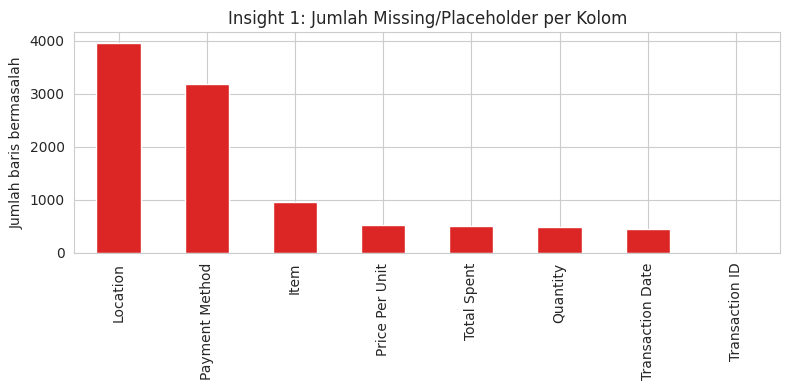

In [5]:
plt.figure(figsize=(8,4))
placeholder_counts.sort_values(ascending=False).plot(kind='bar', color='#dc2626')
plt.title('Insight 1: Jumlah Missing/Placeholder per Kolom')
plt.ylabel('Jumlah baris bermasalah')
plt.tight_layout()
plt.show()

**Insight 1:** Kolom `Payment Method` dan `Location` paling banyak mengandung nilai kosong/placeholder (`ERROR`/`UNKNOWN`/NaN), sehingga akan ditangani dengan kategori `Unknown` (bukan dibuang) agar tidak kehilangan terlalu banyak data.

## 3. Preprocessing dengan `src/data_preprocessing.py`

In [6]:
from data_preprocessing import run_pipeline
df = run_pipeline()
df.head()

Selesai. Data bersih disimpan di: /home/claude/capstone-project/src/../data/processed/cafe_sales_clean.csv
Jumlah baris awal : 10000
Jumlah baris bersih: 7562


,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Inflasi,Year,Month,DayOfWeek,IsWeekend
0,Tea,3.0,1.5,4.5,Digital Wallet,In-store,2023-01-01,5.28,2023,1,6,1
1,Sandwich,1.0,4.0,4.0,Digital Wallet,In-store,2023-01-01,5.28,2023,1,6,1
2,Coffee,5.0,2.0,10.0,Digital Wallet,Unknown,2023-01-01,5.28,2023,1,6,1
3,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-01-01,5.28,2023,1,6,1
4,Tea,5.0,1.5,7.5,Unknown,Takeaway,2023-01-01,5.28,2023,1,6,1


## 4. Analisis Univariat

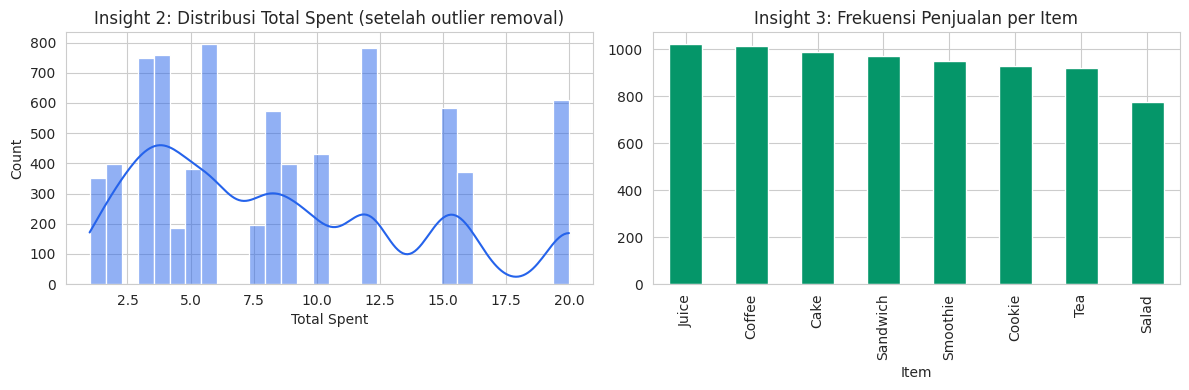

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Total Spent'], bins=30, kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('Insight 2: Distribusi Total Spent (setelah outlier removal)')
df['Item'].value_counts().plot(kind='bar', ax=axes[1], color='#059669')
axes[1].set_title('Insight 3: Frekuensi Penjualan per Item')
plt.tight_layout()
plt.show()

**Insight 2 & 3:** Distribusi `Total Spent` right-skewed (wajar untuk data transaksi ritel). Frekuensi penjualan antar item relatif merata, mengindikasikan tidak ada produk yang mendominasi secara ekstrem.

## 5. Analisis Multivariat & Korelasi

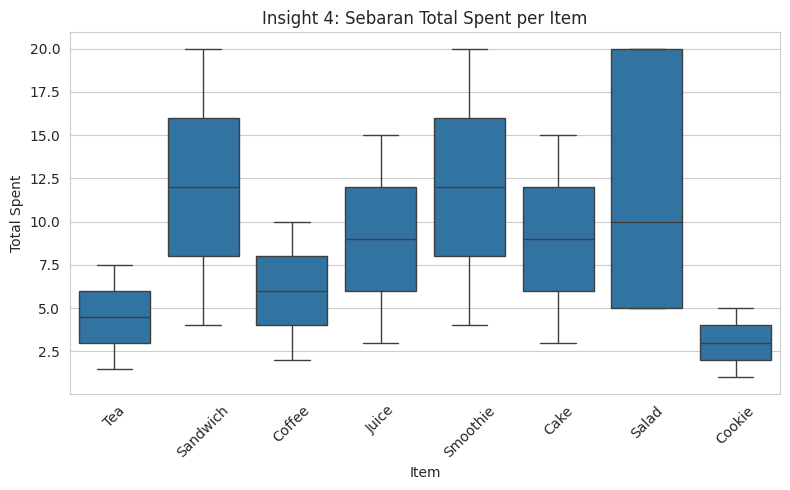

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Item', y='Total Spent')
plt.xticks(rotation=45)
plt.title('Insight 4: Sebaran Total Spent per Item')
plt.tight_layout()
plt.show()

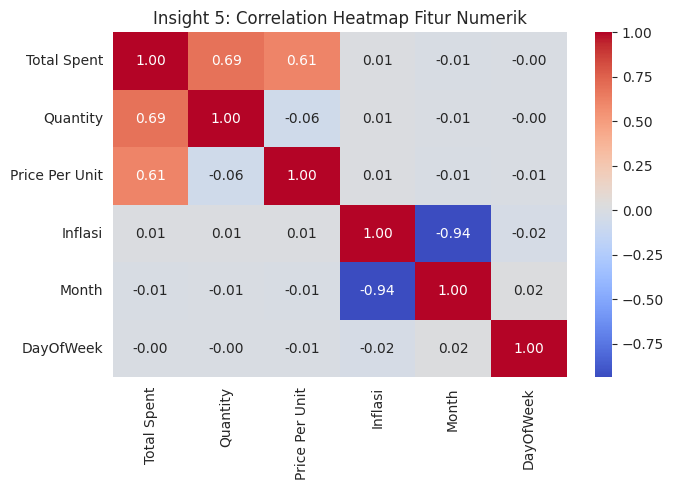

In [9]:
numeric_cols = ['Total Spent', 'Quantity', 'Price Per Unit', 'Inflasi', 'Month', 'DayOfWeek']
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Insight 5: Correlation Heatmap Fitur Numerik')
plt.tight_layout()
plt.show()

**Insight 4 & 5:** Rentang `Total Spent` berbeda-beda antar `Item` (menu lebih mahal jelas berkontribusi pada nilai belanja lebih tinggi). `Total Spent` berkorelasi kuat dengan `Quantity` & `Price Per Unit` (karena secara matematis `Total Spent = Quantity x Price`), namun **korelasi dengan `Inflasi` sangat lemah** -- konsisten dengan temuan awal bahwa penjualan kafe cenderung resilient terhadap fluktuasi makroekonomi jangka pendek. Karena hubungan matematis persis tersebut, `Quantity` dan `Price Per Unit` **tidak dipakai sebagai fitur model** (lihat `02_modeling.ipynb`) untuk menghindari data leakage.

## 6. Feature Engineering & Preprocessing

Langkah preprocessing yang sudah diterapkan pada `src/data_preprocessing.py`:
1. Konversi placeholder `ERROR`/`UNKNOWN` menjadi `NaN`.
2. Konversi tipe data numerik & tanggal.
3. Baris tanpa `Transaction Date`/`Item`/`Quantity`/`Price Per Unit` dibuang (tidak bisa direkonstruksi).
4. `Total Spent` yang kosong direkonstruksi dari `Quantity x Price Per Unit`.
5. `Payment Method` & `Location` kosong diisi kategori `Unknown`.
6. Duplikat `Transaction ID` dibuang.
7. Outlier `Total Spent` dibuang dengan aturan IQR (1.5xIQR).
8. Feature engineering: `Year`, `Month`, `DayOfWeek`, `IsWeekend`, join `Inflasi` bulanan.
9. Encoding: `OneHotEncoder` untuk fitur kategorikal, `StandardScaler` untuk fitur numerik (dilakukan di dalam sklearn Pipeline saat modeling, lihat `02_modeling.ipynb`).

## 7. Train - Validation - Test Split

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Total Spent'])
y = df['Total Spent']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

Train: (5293, 11) | Val: (1134, 11) | Test: (1135, 11)


## Ringkasan 5 Insight Utama
1. Data mentah punya banyak placeholder `ERROR`/`UNKNOWN` terutama di `Payment Method` & `Location`.
2. Distribusi `Total Spent` right-skewed, mayoritas transaksi bernilai kecil-menengah.
3. Frekuensi penjualan antar item relatif merata (tidak ada 1 produk yang mendominasi).
4. Nilai belanja berbeda signifikan antar jenis item (item lebih mahal -> total spent lebih tinggi).
5. Faktor inflasi bulanan berkorelasi sangat lemah terhadap total belanja -> bisnis kafe relatif resilient.